# 제주 버스 도착 시간 예측: 선정 feature 기반 XGBoost 하이퍼파라미터 튜닝

## 이 노트북의 위치

이 노트북은 앞선 수업 노트북을 잇는 후속 자료입니다. 특히 바로 앞 노트북에 이어집니다.

1. `xgboost_jeju_bus_baseline.ipynb` — 데이터 로드부터 학습·평가·예측까지 전체 흐름을 한 번 완성한 baseline 모델을 만들었습니다.
2. `jeju_bus_eda_lecture_commented.ipynb` — 데이터 구조·target 분포·이상치·시간대·요일·노선·정류장·거리와 도착 시간의 관계를 살펴봤습니다.
3. `jeju_bus_xgboost_error_and_feature_experiments_simple.ipynb` — **(바로 앞 노트북)** EDA 기반 `v2_original`을 기준으로 오차 분석을 하고, 위치 관련 feature 실험(`v2_with_dist_segment_name`)과 이상치 제거 실험(상위 1% / IQR)을 진행했습니다.

### 앞 강의 → 이번 강의 흐름

- **앞 강의**: 여러 feature와 이상치 제거 실험을 통해 모델 성능 변화를 확인했습니다.
- **이번 강의**: 앞 강의 결과를 바탕으로 **하나의 최종 후보 조건**을 선택합니다. 그 조건에서 기준 모델 성능을 먼저 측정한 뒤, **동일한 feature·동일한 데이터 조건**에서 XGBoost 하이퍼파라미터를 튜닝합니다.

### 이번 노트북에서 선택한 최종 후보 조건

앞 노트북에서는 기본 feature, 위치 feature, 이상치 제거 실험을 통해 성능 변화를 확인했습니다. 이번 노트북에서는 그 실험 결과를 바탕으로 다음 조건을 **최종 후보 조건**으로 선택합니다.

1. `v2_original` 기본 feature 사용
2. 위치 관련 feature 추가 (`dist_segment_name` + 현재/다음 정류장에서 기준점까지의 거리 feature)
3. target 상위 1% 이상치 제거

이 조건으로 기준 모델(`selected_base_xgb`) 성능을 먼저 측정한 뒤, **feature와 데이터 조건은 고정**하고 XGBoost 하이퍼파라미터만 조정합니다.

> **핵심 메시지** — 이번 노트북에서는 `v2_original`과 직접 비교하지 않습니다.
> 앞 노트북 결과를 바탕으로 선택한 최종 후보 조건인 `selected_base_xgb`를 기준으로 튜닝 효과를 비교합니다.

#### 요리 실험에 비유하면

> 앞 시간에는 재료를 바꿔 보면서 맛이 어떻게 달라지는지 확인했습니다.
> 이번 시간에는 사용할 재료를 하나로 정한 뒤, 불 조절이나 조리 시간을 바꿔 보는 단계입니다.
> 재료(feature)와 양(데이터 조건)을 고정해야, 맛이 달라졌을 때 그 이유를 "불 조절(하이퍼파라미터) 때문"이라고 해석할 수 있습니다.

### 모델 파라미터 vs 하이퍼파라미터

- **모델 파라미터**는 모델이 **학습하면서 스스로 찾아내는 값**입니다. (트리의 분기 기준 등)
- **하이퍼파라미터**는 학습이 시작되기 **전에 사람이 정해 주는 설정값**입니다. (트리를 몇 개 만들지, 얼마나 깊게 만들지 등)

비유하자면, 하이퍼파라미터는 요리를 시작하기 전에 정하는 **불 세기·조리 시간 같은 설정**이고, 모델 파라미터는 그 설정 아래에서 **실제로 익은 정도**에 해당합니다.

> 이 노트북은 위에서 아래로 순서대로 실행하면 전체 흐름이 그대로 재현되도록 구성되어 있습니다.

## 1. 라이브러리 import

튜닝 실험에 필요한 라이브러리를 한 번에 불러옵니다. 각 도구의 역할은 주석으로 함께 설명합니다.

### 시각화 환경 준비 (dtreeviz · Graphviz · 한글 폰트)

이 노트북의 **뒷부분(최적 모델 해석)**에서 `dtreeviz`로 XGBoost 내부 트리를 그림으로 저장합니다. 이 그림 도구는 일반적인 분석 라이브러리보다 **설치·환경 준비**가 조금 더 필요합니다. 그래서 아래 셀들에서 먼저 환경을 준비합니다.

- **패키지 설치**: `dtreeviz`(트리 그림), `graphviz`(그림 엔진의 파이썬 연결 패키지), `svglib`·`reportlab`(SVG → PDF 변환), `cairosvg`(SVG 변환 보조)
- **Graphviz 프로그램 PATH 등록**: `graphviz` 파이썬 패키지와 **별개로**, Graphviz **실행 프로그램**이 따로 설치되어 있어야 그림이 그려집니다. 그 프로그램 위치를 PATH에 추가합니다.
- **한글 폰트 설정**: 그림 안의 한글(정류장명 등)이 깨지지 않도록 Matplotlib에 맑은 고딕 폰트를 등록하고, SVG에서 글자가 깨지지 않도록 설정합니다.

> 참고: 이 환경 준비 셀들은 **dtreeviz 시각화를 위한 사전 준비**일 뿐, 이 노트북의 핵심인 **하이퍼파라미터 튜닝**과는 직접 관련이 없습니다. 환경이 이미 준비되어 있다면 빠르게 지나가도 됩니다. 설치가 어려운 환경이라면 뒤의 트리 저장 셀이 실패할 수 있지만, 그래도 **튜닝·평가 결과에는 영향이 없습니다.**

In [1]:
!pip install dtreeviz graphviz ipykernel cairosvg

In [2]:
import dtreeviz
import graphviz
print("dtreeviz import 성공")
print("graphviz import 성공")

dtreeviz import 성공
graphviz import 성공


In [3]:
# Graphviz "실행 프로그램"의 위치를 PATH(프로그램을 찾는 경로 목록)에 추가합니다.
# 주의: 위에서 설치한 graphviz "파이썬 패키지"와, 그림을 실제로 그리는 Graphviz "실행 프로그램"은 서로 다릅니다.
#       파이썬 패키지만 있고 실행 프로그램이 PATH에 없으면 그림 저장이 실패할 수 있습니다.
# 아래 경로는 Windows에 Graphviz를 기본 설치했을 때의 실행 파일 폴더입니다. (설치 위치가 다르면 경로를 바꿔 주세요.)
import os

graphviz_bin = r"C:\Program Files\Graphviz\bin"

os.environ["PATH"] = graphviz_bin + os.pathsep + os.environ["PATH"]

print("Graphviz PATH 추가 완료:")
print(graphviz_bin)

Graphviz PATH 추가 완료:
C:\Program Files\Graphviz\bin


In [4]:
# SVG 생성 전에 Matplotlib 한글 폰트 설정
# 중요: 이 셀은 dtreeviz SVG를 만들기 전에 반드시 실행해야 합니다.

import matplotlib as mpl
import matplotlib.pyplot as plt
# 핵심 설정 1: 한글 폰트 사용
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 부호가 깨지지 않도록 설정합니다.

# 핵심 설정 2: SVG에서 글자를 path로 바꾸지 않고 text로 남김
# 이 설정이 없으면 한글이 ArialMT-xxxx path로 변환되어 깨질 수 있습니다.
mpl.rcParams["svg.fonttype"] = "none"


In [5]:
from pathlib import Path
import pandas as pd             # 표 형태 데이터를 다루는 라이브러리
import numpy as np              # 수치 계산용 라이브러리 (RMSE 계산 등에 사용)
import warnings                 # 경고 메시지를 제어하는 표준 라이브러리
import time                     # 실행 시간을 측정하는 표준 라이브러리

# 학습/검증 데이터를 나누는 함수
from sklearn.model_selection import train_test_split
# 하이퍼파라미터 후보를 무작위로 탐색하는 도구
from sklearn.model_selection import RandomizedSearchCV
# 컬럼 종류별로 다른 전처리를 한 번에 적용하는 도구
from sklearn.compose import ColumnTransformer
# 전처리와 모델 학습을 하나의 흐름으로 묶는 도구
from sklearn.pipeline import Pipeline
# 범주형(문자) 값을 0/1 형태의 숫자 컬럼으로 펼치는 도구
from sklearn.preprocessing import OneHotEncoder
# 회귀 모델 평가 지표들 (MAE, MSE->RMSE, R2)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 숫자 값을 예측하는 회귀용 XGBoost 모델
from xgboost import XGBRegressor

# 안내성 경고 메시지를 숨겨 수업 흐름의 가독성을 높입니다. (오류가 아니라 경고입니다.)
warnings.filterwarnings("ignore")


## 2. 데이터 로드 및 기본 확인

`jeju_bus.csv`를 읽어 `df`에 저장합니다. 노트북과 같은 폴더에 파일이 있다고 가정합니다.

이번 노트북은 튜닝 실험이 목적이지만, 이 노트북만 따로 실행하는 사람도 데이터 상태를 파악할 수 있도록 **독립 실행 가능성**을 위해 데이터 로드와 기본 확인을 다시 수행합니다. 앞 노트북에서 확인한 내용을 재사용하더라도, 새 노트북에서는 필요한 전처리 과정을 다시 포함해야 위에서 아래로 막힘없이 실행됩니다.

In [6]:
# 같은 폴더에 jeju_bus.csv 가 있다고 가정합니다.
# 파일이 다른 경로에 있으면 read_csv 경로를 수정합니다. 예: pd.read_csv("data/jeju_bus.csv")
df = pd.read_csv("jeju_bus.csv")  # CSV 파일을 읽어 DataFrame(df)으로 만듭니다.
print("jeju_bus.csv 를 정상적으로 불러왔습니다.")


jeju_bus.csv 를 정상적으로 불러왔습니다.


In [7]:
# 상위 5개 행을 확인합니다. 실제 값이 어떤 형태인지 눈으로 점검합니다.
df.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64


In [8]:
# 데이터의 (행 개수, 열 개수)를 확인합니다.
df.shape

(210457, 14)

In [9]:
# 실제 컬럼명을 확인합니다. 이후 feature 목록은 이 이름을 기준으로 작성됩니다.
df.columns

Index(['id', 'date', 'route_id', 'vh_id', 'route_nm', 'now_latitude',
       'now_longitude', 'now_station', 'now_arrive_time', 'distance',
       'next_station', 'next_latitude', 'next_longitude', 'next_arrive_time'],
      dtype='str')

In [10]:
# 각 컬럼의 자료형(숫자/문자)과 결측치 여부를 한눈에 확인합니다.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210457 entries, 0 to 210456
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                210457 non-null  int64  
 1   date              210457 non-null  str    
 2   route_id          210457 non-null  int64  
 3   vh_id             210457 non-null  int64  
 4   route_nm          210457 non-null  str    
 5   now_latitude      210457 non-null  float64
 6   now_longitude     210457 non-null  float64
 7   now_station       210457 non-null  str    
 8   now_arrive_time   210457 non-null  str    
 9   distance          210457 non-null  float64
 10  next_station      210457 non-null  str    
 11  next_latitude     210457 non-null  float64
 12  next_longitude    210457 non-null  float64
 13  next_arrive_time  210457 non-null  int64  
dtypes: float64(5), int64(4), str(5)
memory usage: 22.5 MB


In [11]:
# 컬럼별 결측치(비어 있는 값) 개수를 확인합니다.
df.isnull().sum()

id                  0
date                0
route_id            0
vh_id               0
route_nm            0
now_latitude        0
now_longitude       0
now_station         0
now_arrive_time     0
distance            0
next_station        0
next_latitude       0
next_longitude      0
next_arrive_time    0
dtype: int64

## 3. 원본 데이터 보존 및 모델링용 복사본 생성

원본 `df`는 보존하고, 모델링용 복사본 `df_model`을 만들어 사용합니다.

- 원본 데이터를 직접 수정하면, 처음 상태로 되돌아가기 어렵습니다.
- 모델링 과정에서는 날짜에서 뽑아낸 파생 컬럼을 추가하므로, 이런 변형은 복사본에만 적용하는 것이 안전합니다.

#### 이상치는 왜 제거하지 않나요?

앞 노트북에서는 상위 1% target 제거, IQR 기준 target 이상치 제거 실험을 했습니다. 하지만 이번 튜닝 노트북에서는 **원본 데이터를 그대로 사용**합니다.

- 이상치를 제거하면 평가 대상 데이터(test set)가 달라지기 때문에, 기준 모델과 튜닝 모델의 성능 차이를 직접 비교하기 어려워질 수 있습니다.
- 이번에는 데이터 조건을 고정하고, **하이퍼파라미터 변경이 성능에 어떤 영향을 주는지** 확인하는 데 집중합니다.

In [12]:
# 원본 df는 보존하고, 모델링용 복사본 df_model을 만듭니다.
df_model = df.copy()

# target(정답) 컬럼명을 변수로 지정해 둡니다. 이번 문제의 정답은 next_arrive_time 입니다.
target_col = "next_arrive_time"

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64


## 4. 날짜·시간 및 위치 feature 생성

`date`와 `now_arrive_time`에서 시간 관련 feature를 만들고, 이어서 정류장 좌표로 **위치 관련 feature**도 만듭니다.

- 시간 feature: `day`, `dayofweek`, `now_hour` (이번 노트북의 기본 feature로 사용)
- `year`, `month`도 만들 수 있지만, 이 데이터는 짧은 기간에 모여 있어 거의 고정값이므로 **모델 feature로는 사용하지 않습니다.**
- 위치 feature: 정류장 좌표를 4개 기준점과 비교해 만든 권역·거리 feature (바로 아래 위치 feature 셀에서 생성)

처리 전에 실제 값의 형식을 먼저 확인합니다. 형식을 추측해 고정 규칙을 적용하면, 형식이 조금만 달라도 실행이 멈추기 때문입니다.

In [13]:
# 변환에 사용할 두 컬럼의 실제 값 형식을 먼저 눈으로 확인합니다.
df_model[["date", "now_arrive_time"]].head()

,date,now_arrive_time
0,2019-10-15,06시
1,2019-10-15,06시
2,2019-10-15,06시
3,2019-10-15,06시
4,2019-10-15,07시


이 데이터에서는 `date`가 `2019-10-15` 같은 날짜 문자열이고, `now_arrive_time`은 `"06시"`처럼 **시(hour) 단위만** 담긴 문자열입니다. 형식에 맞춰 안정적으로 변환합니다.

- 날짜 문자열은 그대로는 모델이 다루기 어렵습니다. 요일·일로 나눠 숫자로 주면 반복 패턴을 학습할 수 있습니다.
- 도착 시간 문자열에서 시간대(`now_hour`)를 뽑으면 시간대별 교통 패턴을 반영할 수 있습니다.
- `errors="coerce"`는 변환할 수 없는 값을 결측치로 바꿔, 잘못된 값 하나 때문에 전체 실행이 멈추지 않게 합니다.

In [14]:
# 1) date를 날짜형(datetime)으로 변환합니다. (변환 불가 값은 NaT 로 처리)
df_model["date"] = pd.to_datetime(df_model["date"], errors="coerce")

# 2) 날짜에서 숫자 파생 컬럼을 만듭니다.
#    year, month 도 만들어 두지만, 이번 모델 feature 로는 사용하지 않습니다.
df_model["year"] = df_model["date"].dt.year          # 연도 (모델 feature 미사용)
df_model["month"] = df_model["date"].dt.month        # 월   (모델 feature 미사용)
df_model["day"] = df_model["date"].dt.day            # 일
df_model["dayofweek"] = df_model["date"].dt.dayofweek  # 요일 (월=0 ... 일=6)

# now_arrive_time 은 "06시"처럼 시(hour)만 담긴 문자열입니다. 여기서 숫자 시간대(now_hour)를 뽑습니다.
# 출근·퇴근 시간대에는 교통 상황이 달라질 수 있으므로, 시간대는 도착 시간 예측에 중요한 feature 가 될 수 있습니다.
df_model["now_hour"] =  df_model["now_arrive_time"].astype(str).str.extract(r"(\d+)").astype(float)

df_model[["date", "day", "dayofweek", "now_arrive_time", "now_hour"]].head()

,date,day,dayofweek,now_arrive_time,now_hour
0,2019-10-15,15,1,06시,6.0
1,2019-10-15,15,1,06시,6.0
2,2019-10-15,15,1,06시,6.0
3,2019-10-15,15,1,06시,6.0
4,2019-10-15,15,1,07시,7.0


### 위치 관련 feature 생성 (앞 노트북과 동일한 방식)

앞 노트북(`jeju_bus_xgboost_error_and_feature_experiments_simple.ipynb`)의 `v2_with_dist_segment_name` 실험에서 사용한 **위치 feature**를 이 노트북에서도 동일하게 만듭니다. (이 노트북만 따로 실행해도 막힘없이 돌아가도록, 위치 feature 생성 코드를 다시 포함합니다.)

- 제주도 내 4개 기준점(`up`, `right`, `center`, `down`)까지의 거리를 계산합니다.
- 각 정류장에서 가장 가까운 기준점 이름을 권역(`now_dist_name`, `next_dist_name`)으로 쓰고, 둘을 이어 `dist_segment_name`을 만듭니다.
- 거리 숫자(`now_dist_to_*`, `next_dist_to_*`)도 feature로 함께 사용합니다.

거리 계산은 별도 패키지 없이 **numpy 기반 vectorized Haversine** 방식을 사용합니다. (행마다 반복 계산하지 않고 컬럼 전체를 한 번에 계산해 빠릅니다. 수식을 외우는 것이 목적은 아닙니다.)

In [15]:
# 위도/경도 사이 거리를 km 로 계산하는 함수입니다. (앞 노트북과 동일한 numpy 기반 Haversine)
def calculate_distance_km(lat1, lon1, lat2, lon2):
    """
    두 위도/경도 지점 사이의 거리를 km 단위로 계산합니다.
    pandas Series(컬럼 전체)도 한 번에 받을 수 있어, 행마다 반복 계산하지 않아도 됩니다.
    (수식을 외우는 것이 목적은 아니며, 좌표로 거리 feature를 빠르게 만든다는 점이 중요합니다.)
    """
    earth_radius_km = 6371  # 지구 반지름(km)

    # 각도를 라디안으로 바꿉니다. (삼각함수 계산을 위해 필요)
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c




In [16]:
# 제주도 내 주요 기준 지점 4개 (위도, 경도). 앞 노트북과 동일한 기준점을 사용합니다.
reference_points = {
    "up": (33.506286, 126.490312),       # 제주공항 방면
    "right": (33.493521, 126.895326),    # 성산일출봉 방면
    "center": (33.379724, 126.545315),   # 한라산 / 중산간
    "down": (33.246742, 126.562387),     # 서귀포시 방면
}

In [17]:
def assign_region_info(data, lat_col, lon_col):

    # 1. 각 기준점의 위도/경도 값을 꺼냅니다.
    up_lat, up_lon = reference_points["up"]
    down_lat, down_lon = reference_points["down"]
    right_lat, right_lon = reference_points["right"]
    center_lat, center_lon = reference_points["center"]

    # 2. 각 정류장에서 4개 기준점까지의 거리를 계산합니다.
    distance_to_up = calculate_distance_km(   data[lat_col], data[lon_col], up_lat, up_lon )
    distance_to_down = calculate_distance_km(  data[lat_col], data[lon_col], down_lat, down_lon    )
    distance_to_right = calculate_distance_km(  data[lat_col], data[lon_col], right_lat, right_lon   )
    distance_to_center = calculate_distance_km( data[lat_col],  data[lon_col],   center_lat,  center_lon  )
    
    # 3. 가장 가까운 권역 이름을 찾기 위한 거리표를 만듭니다.
    # 여기서는 컬럼명을 up, down, right, center로 둬야
    # idxmin(axis=1)의 결과가 바로 권역 이름이 됩니다.
    distance_table = pd.DataFrame({
        "up": distance_to_up,
        "down": distance_to_down,
        "right": distance_to_right,
        "center": distance_to_center
    }, index=data.index)

    # 4. 각 행에서 가장 가까운 기준점 이름을 찾습니다.
    nearest_region = distance_table.idxmin(axis=1)

    # 5. 최종 반환용 DataFrame을 만듭니다.
    # 거리 컬럼명은 모델 feature로 쓰기 좋게 명확하게 작성합니다.
    result = pd.DataFrame({
        "dist_name": nearest_region,
        "dist_to_up": distance_to_up,
        "dist_to_down": distance_to_down,
        "dist_to_right": distance_to_right,
        "dist_to_center": distance_to_center
    }, index=data.index)

    return result

In [18]:
# 현재 정류장 기준 권역 정보 계산
now_region_info = assign_region_info(
    df_model,
    "now_latitude",
    "now_longitude"
)

now_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,7.962505,23.319056,32.135034,8.532122
1,up,8.003869,23.473015,31.905930,8.710701
2,up,8.158338,23.582519,31.583874,8.861671
3,up,5.774762,25.961685,32.635035,11.118256
4,up,2.332803,27.295447,37.141639,12.673969


In [19]:
# 다음 정류장 기준 권역 정보 계산
next_region_info = assign_region_info(
    df_model,
    "next_latitude",
    "next_longitude"
)

next_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,8.003869,23.473015,31.905930,8.710701
1,up,8.158338,23.582519,31.583874,8.861671
2,up,8.387595,23.701416,31.175511,9.041978
3,up,5.429627,26.539110,32.693959,11.692688
4,up,2.276139,27.400941,37.514443,12.832868


In [20]:
# 현재 정류장 권역 이름과 거리 저장
df_model["now_dist_name"] = now_region_info["dist_name"]
df_model["now_dist_to_up"] = now_region_info["dist_to_up"]
df_model["now_dist_to_down"] = now_region_info["dist_to_down"]
df_model["now_dist_to_right"] = now_region_info["dist_to_right"]
df_model["now_dist_to_center"] = now_region_info["dist_to_center"]


df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,year,month,day,dayofweek,now_hour,now_dist_name,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,...,2019,10,15,1,6.0,up,7.962505,23.319056,32.135034,8.532122
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,...,2019,10,15,1,6.0,up,8.003869,23.473015,31.905930,8.710701
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,...,2019,10,15,1,6.0,up,8.158338,23.582519,31.583874,8.861671
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,...,2019,10,15,1,6.0,up,5.774762,25.961685,32.635035,11.118256
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,...,2019,10,15,1,7.0,up,2.332803,27.295447,37.141639,12.673969


In [21]:
# 다음 정류장 권역 이름과 거리 저장
df_model["next_dist_name"] = next_region_info["dist_name"]
df_model["next_dist_to_up"] = next_region_info["dist_to_up"]
df_model["next_dist_to_down"] = next_region_info["dist_to_down"]
df_model["next_dist_to_right"] = next_region_info["dist_to_right"]
df_model["next_dist_to_center"] = next_region_info["dist_to_center"]


df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,now_dist_name,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center,next_dist_name,next_dist_to_up,next_dist_to_down,next_dist_to_right,next_dist_to_center
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,...,up,7.962505,23.319056,32.135034,8.532122,up,8.003869,23.473015,31.905930,8.710701
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,...,up,8.003869,23.473015,31.905930,8.710701,up,8.158338,23.582519,31.583874,8.861671
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,...,up,8.158338,23.582519,31.583874,8.861671,up,8.387595,23.701416,31.175511,9.041978
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,...,up,5.774762,25.961685,32.635035,11.118256,up,5.429627,26.539110,32.693959,11.692688
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,...,up,2.332803,27.295447,37.141639,12.673969,up,2.276139,27.400941,37.514443,12.832868


In [22]:
# 현재 정류장 권역과 다음 정류장 권역을 조합한 feature 생성
df_model["dist_segment_name"] = (
    df_model["now_dist_name"].astype(str)
    + " → "
    + df_model["next_dist_name"].astype(str)
)

df_model

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center,next_dist_name,next_dist_to_up,next_dist_to_down,next_dist_to_right,next_dist_to_center,dist_segment_name
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,...,7.962505,23.319056,32.135034,8.532122,up,8.003869,23.473015,31.905930,8.710701,up → up
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,...,8.003869,23.473015,31.905930,8.710701,up,8.158338,23.582519,31.583874,8.861671,up → up
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,...,8.158338,23.582519,31.583874,8.861671,up,8.387595,23.701416,31.175511,9.041978,up → up
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,...,5.774762,25.961685,32.635035,11.118256,up,5.429627,26.539110,32.693959,11.692688,up → up
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,...,2.332803,27.295447,37.141639,12.673969,up,2.276139,27.400941,37.514443,12.832868,up → up
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210452,210452,2019-10-28,405328102,7983486,281-2,33.255783,126.577450,비석거리,21시,528.0,...,29.005930,1.724127,39.624369,14.101369,down,29.345088,1.256942,40.123236,14.468773,down → down
210453,210453,2019-10-28,405328102,7983486,281-2,33.248595,126.568527,동문로터리,21시,280.0,...,29.560001,0.607018,40.775774,14.739550,down,29.377265,0.471628,40.867894,14.578870,down → down
210454,210454,2019-10-28,405328102,7983486,281-2,33.251891,126.560303,서귀포시 구 버스터미널,21시,114.0,...,29.024374,0.604451,41.106369,14.282445,down,29.096335,0.550141,41.217986,14.365152,down → down
210455,210455,2019-10-28,405328102,7983486,281-2,33.251084,126.559551,아랑조을거리 입구,21시,223.0,...,29.096335,0.550141,41.217986,14.365152,down,29.237779,0.505603,41.437302,14.528214,down → down


In [23]:
# 조합 권역이 몇 종류인지, 어떤 조합이 많은지 확인
print("dist_segment_name 고유값 개수:", df_model["dist_segment_name"].nunique())
df_model["dist_segment_name"].value_counts()

dist_segment_name 고유값 개수: 12


dist_segment_name
up → up            121131
down → down         48377
right → right       34032
center → center      5512
center → up           321
right → up            276
up → center           207
down → right          144
up → right            137
right → down          134
down → center          95
center → down          91
Name: count, dtype: int64

## 5. 최종 후보 feature 구성 정의

이번 노트북에서는 앞 노트북의 실험 결과를 바탕으로 선택한 **최종 후보 feature**를 고정합니다. 이 구성은 앞 노트북의 `v2_with_dist_segment_name` 실험과 일관됩니다.

#### `v2_with_dist_segment_name`은 사실 거리 feature도 함께 씁니다

여기서 `v2_with_dist_segment_name`은 이름만 보면 `dist_segment_name` 하나만 추가한 것처럼 보일 수 있습니다. 하지만 앞 노트북의 실험에서는 `dist_segment_name`뿐 아니라 **현재 정류장과 다음 정류장에서 4개 기준점까지의 거리 feature**(`now_dist_to_*`, `next_dist_to_*`)도 함께 사용했습니다.

따라서 이번 노트북에서도 앞 노트북의 실험 조건과 맞추기 위해 **거리 숫자 feature와 `dist_segment_name`을 함께** 사용합니다.

#### 왜 feature를 더 바꾸지 않나요?

- 최종 후보 조건을 **하나로 고정**한 뒤, 이번 노트북에서는 **하이퍼파라미터만** 바꿉니다.
- 그래야 성능 변화가 feature 때문인지 파라미터 때문인지 구분하기 쉽습니다. (변수를 하나만 바꿔야 그 효과를 알 수 있습니다.)
- `speed`는 데이터 누수 위험 때문에 제외합니다. (이 데이터셋에는 컬럼 자체도 없습니다.)
- `station_segment`는 앞 노트북의 또 다른 실험 feature이므로, 이번 최종 후보에는 넣지 않습니다.

In [24]:
# 이번 노트북에서 고정할 최종 후보 feature 입니다.
# (v2_original 기본 feature + 위치 관련 거리 feature + dist_segment_name)
# 숫자형/범주형을 나누는 이유: 범주형(문자)만 One-Hot Encoding 으로 숫자 컬럼으로 바꿔야 모델이 쓸 수 있기 때문입니다.
selected_numeric_features = [
    "distance",
    "day",
    "dayofweek",
    "now_hour",
    "now_dist_to_up",
    "now_dist_to_down",
    "now_dist_to_right",
    "now_dist_to_center",
    "next_dist_to_up",
    "next_dist_to_down",
    "next_dist_to_right",
    "next_dist_to_center",
]

In [25]:
selected_categorical_features = [
    "route_nm",
    "now_station",
    "next_station",
    "dist_segment_name",
]

In [26]:

# 전체 feature 목록
selected_features = selected_numeric_features + selected_categorical_features

selected_features 

['distance',
 'day',
 'dayofweek',
 'now_hour',
 'now_dist_to_up',
 'now_dist_to_down',
 'now_dist_to_right',
 'now_dist_to_center',
 'next_dist_to_up',
 'next_dist_to_down',
 'next_dist_to_right',
 'next_dist_to_center',
 'route_nm',
 'now_station',
 'next_station',
 'dist_segment_name']

### 상위 1% target 이상치 제거 (학습 전 적용)

앞 노트북에서 실험한 **상위 1% target 이상치 제거**를 이번 노트북의 **기준 데이터 조건**으로 적용합니다.

- 상위 1% 제거 기준은 target 컬럼인 `next_arrive_time` 기준으로 계산합니다.
- 제거는 반드시 **`train_test_split` 전에** 적용합니다. 그래야 기준 모델과 튜닝 모델이 모두 같은 데이터 조건에서 비교됩니다.
- 이번 노트북에서는 이상치 제거 자체를 다시 실험하는 것이 아니라, **앞 노트북의 실험 결과를 바탕으로 상위 1% 제거 조건을 선택한 상태**에서 튜닝을 진행합니다.
- (참고: IQR 기준 이상치 제거는 앞 노트북의 보충 실험이며, 이번 노트북에서는 상위 1% 제거 조건만 사용합니다.)

In [27]:
# target 상위 1% 경계값(99% 분위수)을 구합니다. 이 값보다 큰 행(아주 긴 지연)을 제거합니다.
upper_1pct = df_model[target_col].quantile(0.99)

upper_1pct


np.float64(340.0)

In [28]:
# 원본 df_model 은 그대로 두고, 상위 1% 를 제거한 별도 데이터프레임을 만듭니다.
df_model_selected = df_model[df_model[target_col] <= upper_1pct].copy()

print("원본 데이터 행 수:", len(df_model))
print("상위 1% target 제거 후 행 수:", len(df_model_selected))
print("제거된 행 수:", len(df_model) - len(df_model_selected))
print("상위 1% 제거 기준값:", upper_1pct)

원본 데이터 행 수: 210457
상위 1% target 제거 후 행 수: 208355
제거된 행 수: 2102
상위 1% 제거 기준값: 340.0


## 6. train/test split

상위 1% 제거 후의 `df_model_selected`에서 `X`, `y`를 **다시 생성**한 뒤 학습용/검증용으로 나눕니다. (원본 `df_model`에서 만든 X, y 를 재사용하지 않습니다. 데이터 조건을 선택 조건으로 맞춰야 하기 때문입니다.)

핵심 원칙입니다.

- 기준 모델(`selected_base_xgb`), 수동 튜닝 모델, RandomizedSearchCV 최적 모델은 **모두 같은 train/test split**을 사용합니다.
- 그래야 파라미터 변경 효과를 공정하게 비교할 수 있습니다. (같은 시험지를 써야 점수를 비교할 수 있습니다.)
- 재현성을 위해 `test_size=0.2`, `random_state=42`를 사용합니다.
- 이번 노트북에서는 feature와 데이터 조건(상위 1% 제거)을 고정하고, **XGBoost 설정값만** 바꿔 비교합니다.

In [29]:
# 상위 1% 제거 후의 df_model_selected 에서 X, y 를 다시 만듭니다. (원본 df_model 의 X, y 재사용 금지)
X = df_model_selected[selected_features]
y = df_model_selected[target_col]

# 학습용 80% / 검증용 20% 로 나눕니다. random_state=42 로 매번 같은 분리를 재현합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("학습용 크기:", X_train.shape, "/ 검증용 크기:", X_test.shape)

학습용 크기: (166684, 16) / 검증용 크기: (41671, 16)


## 7. 공통 전처리 작성 (앞 노트북과 동일)

모든 모델이 **같은 전처리**를 쓰도록 전처리기를 한 번만 정의합니다. 전처리 방식은 앞 노트북의 실험과 동일합니다.

- 범주형 컬럼(`selected_categorical_features`) → `OneHotEncoder(handle_unknown="ignore")`로 0/1 컬럼으로 펼칩니다.
- 숫자형 컬럼 → 별도 변환 없이 **그대로 통과**시킵니다. (`remainder="passthrough"`)

`OneHotEncoder(handle_unknown="ignore")`는 학습 때 보지 못한 새 범주(새 노선명·정류장명 등)가 와도 오류 없이 0으로 처리합니다.

#### 왜 StandardScaler와 결측치 대체를 쓰지 않나요?

- XGBoost 같은 **트리 기반 모델**은 값의 크기보다 분기 기준을 보기 때문에 `StandardScaler` 같은 표준화가 **필수는 아닙니다.**
- 이번 노트북의 목적은 전처리 개선이 아니라 **하이퍼파라미터 튜닝**입니다. 전처리를 앞 노트북과 똑같이 고정해 두어야, 이후 성능 변화를 **하이퍼파라미터 변경 효과로 해석**할 수 있습니다.

In [30]:
# 앞 노트북과 동일한 단순 전처리입니다.
# - 범주형 feature 는 OneHotEncoder 로 0/1 숫자 컬럼으로 변환합니다.
#   handle_unknown="ignore": 학습 때 못 본 새 범주가 와도 오류 없이 처리합니다.
# - remainder="passthrough": 나머지 숫자형 feature 는 변환 없이 그대로 모델에 전달합니다.
#   (XGBoost 같은 트리 모델은 숫자 크기 스케일을 맞출 필요가 없습니다.)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), selected_categorical_features),
    ],
    remainder="passthrough",
)

print("전처리기(preprocessor) 준비 완료 (앞 노트북과 동일한 구성)")

전처리기(preprocessor) 준비 완료 (앞 노트북과 동일한 구성)


## 8. 공통 평가 함수 작성

여러 모델을 같은 기준으로 비교하기 위해, 반복되는 평가 계산을 함수 하나로 묶습니다.

- **MAE**: 평균적으로 얼마나 틀리는지. 작을수록 좋습니다.
- **RMSE**: 큰 오차에 더 민감합니다. (`np.sqrt(mean_squared_error(...))` 방식으로 계산해 버전 호환성을 확보합니다.)
- **R2**: target의 변동을 얼마나 설명하는지. 1에 가까울수록 좋습니다.

In [31]:
def evaluate_regression_model(model_name, description, y_true, y_pred):
    """
    회귀 모델의 예측 결과를 평가하는 함수입니다.

    MAE는 평균적으로 얼마나 틀렸는지 확인하는 지표입니다.
    RMSE는 큰 오차에 더 민감하게 반응하는 지표입니다.
    R2는 target의 변동을 모델이 어느 정도 설명하는지 보여주는 지표입니다.
    """
    mae = mean_absolute_error(y_true, y_pred)
    # 버전 호환성을 위해 squared=False 대신 np.sqrt로 RMSE를 계산합니다.
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"[{model_name}] MAE: {mae:.4f} | RMSE: {rmse:.4f} ")

    return {
        "model_name": model_name,
        "description": description,
        "MAE": mae,
        "RMSE": rmse
    }

## 9. 공통 모델 학습 함수 작성

수동 튜닝 실험에서는 "파라미터만 바꿔 같은 흐름으로 학습·평가"하는 코드가 반복됩니다. 이를 `train_xgb_pipeline()` 함수로 묶습니다. (흐름이 숨겨지지 않도록 함수 내부에도 주석을 충분히 답니다.)

#### 병렬 처리(n_jobs)에 대한 중요한 안내

- 수동 튜닝에서는 모델을 하나씩만 학습하므로, 각 XGBoost가 CPU를 모두 쓰도록 `n_jobs=-1`을 사용할 수 있습니다.
- 그러나 **RandomizedSearchCV** 단계에서는 다릅니다. 그 도구가 **여러 조합을 동시에** 돌리는데, 그 안의 XGBoost도 동시에 CPU를 모두 쓰려 하면 **병렬 안에 병렬(중첩 병렬)**이 되어 CPU를 과도하게 점유합니다.
- 그래서 자동 튜닝에서는 `RandomizedSearchCV(n_jobs=-1)` + `XGBRegressor(n_jobs=1)` 조합을 씁니다. 바깥(조합 단위)에서만 병렬을 쓰고, 안쪽 모델은 한 코어만 쓰게 하는 것입니다.

비유하자면, 여러 요리를 동시에 만들 때(바깥 병렬) 각 요리사가 또 보조 여러 명을 부르면(안쪽 병렬) 주방이 사람으로 꽉 차 버립니다. 한쪽에서만 인원을 늘리는 것이 효율적입니다.

In [32]:
def train_xgb_pipeline(model_name, description, xgb_params):
    # 전달받은 하이퍼파라미터로 XGBoost 회귀 모델을 만듭니다.
    # 수동 튜닝에서는 한 번에 한 모델만 학습하므로 n_jobs=-1 로 CPU를 충분히 사용합니다.
    xgb_model = XGBRegressor(
        objective="reg:squarederror",  # 회귀: 제곱 오차를 줄이도록 학습
        random_state=42,               # 재현성 확보
        n_jobs=-1,                     # 가용 CPU 최대 사용 (수동 튜닝에서는 안전)
        **xgb_params                   # 실험마다 달라지는 하이퍼파라미터
    )

    # 고정된 전처리기와 모델을 하나의 파이프라인으로 묶습니다.
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model),
    ])

    # 같은 X_train, y_train 으로 학습합니다. (split 고정)
    model_pipeline.fit(X_train, y_train)
    # 같은 X_test 로 예측합니다.
    y_pred = model_pipeline.predict(X_test)

    # 평가 결과를 만듭니다.
    evaluation = evaluate_regression_model(
        model_name=model_name,
        description=description,
        y_true=y_test,
        y_pred=y_pred,
    )

    return {
        "model_name": model_name,
        "pipeline": model_pipeline,
        "y_pred": y_pred,
        "evaluation": evaluation,
    }

## 10. 선정 조건 기준 모델 학습 — selected_base_xgb

이제 **선정 조건 기준 모델(`selected_base_xgb`)**을 학습합니다. 이 모델이 이번 노트북의 **비교 기준**입니다.

이 기준 모델은 다음 조건을 사용합니다.

- `v2_original` 기본 feature + 위치 관련 feature
- target 상위 1% 이상치 제거 데이터(`df_model_selected`)
- 기본 XGBoost 파라미터 (`n_estimators=200`, `learning_rate=0.05`, `max_depth=5`)

> 이번 노트북의 기준 모델은 `selected_base_xgb`입니다. 이 모델은 앞 노트북의 `v2_original`과 **직접 비교하기 위한 모델이 아니라**, 앞 노트북의 실험 결과를 바탕으로 선택한 **최종 후보 조건**입니다.
>
> 따라서 이번 노트북에서는 `selected_base_xgb`와 튜닝 모델들을 비교합니다. 즉, 같은 feature와 같은 데이터 조건에서 **파라미터 변경 효과만** 확인합니다.

In [33]:
# 선정 조건 기준 모델의 하이퍼파라미터 (기본 설정)
base_params = {
    "n_estimators": 200,    # 만들 트리 개수
    "learning_rate": 0.05,  # 각 트리의 보정 반영 비율
    "max_depth": 5,         # 각 트리의 최대 깊이
}

# 기준 모델을 학습하고 평가합니다. 이후 모든 튜닝 모델은 이 모델과 비교합니다.
selected_base_result = train_xgb_pipeline(
    model_name="selected_base_xgb",
    description="선정 조건 기준 모델 (v2 + 위치 feature + 상위 1% 제거, 기본 파라미터)",
    xgb_params=base_params,
)

[selected_base_xgb] MAE: 22.0203 | RMSE: 30.3539 


## 11. 주요 하이퍼파라미터 개념

XGBoost는 여러 개의 작은 결정트리를 차례로 만들면서, 앞 트리가 틀린 부분을 다음 트리가 보정해 나가는 모델입니다. 이때 사람이 정해 주는 주요 설정값은 다음과 같습니다.

| 파라미터 | 의미 | 강의용 설명 |
| --- | --- | --- |
| `n_estimators` | 트리 개수 | 몇 개의 나무를 만들 것인가 |
| `learning_rate` | 학습률 | 한 번에 얼마나 크게 수정할 것인가 |
| `max_depth` | 트리 최대 깊이 | 한 나무가 얼마나 복잡한 규칙을 만들 수 있는가 |
| `subsample` | 행 샘플링 비율 | 학습할 때 전체 행 중 일부만 사용할 비율 |
| `colsample_bytree` | 컬럼 샘플링 비율 | 각 트리가 사용할 feature 비율 |
| `reg_alpha` | L1 규제 | 불필요한 feature의 영향을 줄이는 방향의 규제 |
| `reg_lambda` | L2 규제 | 모델이 과하게 흔들리지 않도록 완화하는 규제 |

#### 비유로 이해하기

- **`n_estimators`(트리 개수)**: 회의에 참여하는 **판단자 수**와 비슷합니다. 너무 적으면 의견이 부족하고, 너무 많으면 회의가 길어지고 과적합 위험도 생깁니다.
- **`learning_rate`(학습률)**: 한 번에 **얼마나 조심스럽게 의견을 수정**할지에 가깝습니다. 크면 빨리 가지만 거칠고, 작으면 신중하지만 더 많은 트리가 필요합니다.
- **`max_depth`(깊이)**: 한 판단자가 만들 수 있는 **규칙의 복잡도**입니다. 깊을수록 복잡한 패턴을 잡지만 과적합 위험이 커집니다.
- **`subsample`, `colsample_bytree`(샘플링)**: 매번 **일부 데이터와 일부 컬럼만** 보게 해서, 한쪽에 치우쳐 외우는 것을 막아 **과적합을 줄이는 장치**로 볼 수 있습니다.
- **`reg_alpha`, `reg_lambda`(규제)**: 모델이 지나치게 복잡해지거나 특정 값에 과하게 의존하지 않도록 **제동을 거는 장치**입니다.

> 용어 참고 — **과적합(overfitting)**: 모델이 학습 데이터에만 지나치게 맞춰져, 처음 보는 데이터에서는 오히려 성능이 떨어지는 현상입니다.

#### 참고: 이번에 튜닝하는 파라미터 vs 그 외 파라미터

위 표의 파라미터 중 이번 `RandomizedSearchCV`에서 실제로 탐색하는 것은 `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree` 입니다. (규제 `reg_alpha`, `reg_lambda`는 위 수동 실험에서만 다룹니다.)

XGBoost에는 이 밖에도 자주 쓰이는 설정이 더 있습니다. 지금 당장 외울 필요는 없고 "이런 것도 있구나" 정도로만 알아 두면 됩니다.

- `min_child_weight`: 너무 적은 데이터로 가지를 더 나누지 않도록 막는 값 (과적합 완화)
- `gamma`: 가지를 더 나눌 때 요구하는 **최소 개선량**. 값이 크면 더 보수적으로 나눕니다.
- `objective`: 모델이 풀 문제의 종류 지정. 여기서는 회귀라서 `reg:squarederror`를 씁니다.
- `eval_metric`: 학습 중 성능을 재는 기준 (예: `rmse`, `mae`)

> 비유: `max_depth`는 스무고개에서 질문을 몇 단계까지 이어갈지, `learning_rate`는 한 번에 내딛는 보폭, `n_estimators`는 작은 판단 나무를 몇 그루 세울지를 정하는 값입니다.

## 12. 수동 튜닝 실험

자동 탐색으로 바로 가면 결과는 얻을 수 있지만, **왜 그런 결과가 나왔는지** 이해하기 어렵습니다. 그래서 먼저 대표 실험 몇 가지로 깊이·트리 수·학습률·규제의 영향을 직접 확인합니다.

| 모델명 | 설정 | 실험 의도 |
| --- | --- | --- |
| `selected_base_xgb` | n_estimators=200, lr=0.05, max_depth=5 | 선정 조건 기준 모델 |
| `shallow_xgb` | n_estimators=200, lr=0.05, max_depth=3 | 모델을 단순하게 만들었을 때 |
| `deep_xgb` | n_estimators=200, lr=0.05, max_depth=8 | 모델을 복잡하게 만들었을 때 |
| `slow_learning_xgb` | n_estimators=400, lr=0.03, max_depth=5 | 조금씩 천천히 더 많이 학습했을 때 |

각 모델은 위에서 만든 `train_xgb_pipeline()`으로 학습합니다. **feature와 데이터 조건(상위 1% 제거)은 고정하고, 파라미터만** 바꿉니다.

> 이번 튜닝에서는 feature와 데이터 조건을 바꾸지 않습니다. 바꾸는 것은 XGBoost의 설정값입니다.
> 즉, 같은 재료로 불 세기와 조리 시간을 바꿔 보는 실험입니다.

In [34]:
# (1) shallow_xgb: 깊이를 3으로 줄여 더 단순한 모델을 만듭니다.
shallow_result = train_xgb_pipeline(
    model_name="shallow_xgb",
    description="얕은 트리 (max_depth=3) — 단순한 모델",
    xgb_params={"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3},
)

[shallow_xgb] MAE: 24.6185 | RMSE: 33.1101 


In [35]:
# (2) deep_xgb: 깊이를 8로 늘려 더 복잡한 모델을 만듭니다.
deep_result = train_xgb_pipeline(
    model_name="deep_xgb",
    description="깊은 트리 (max_depth=8) — 복잡한 모델",
    xgb_params={"n_estimators": 200, "learning_rate": 0.05, "max_depth": 8},
)

[deep_xgb] MAE: 19.7910 | RMSE: 28.3630 


In [36]:
# (3) slow_learning_xgb: 학습률을 낮추고(0.03) 트리 수를 늘려(400) 천천히 더 많이 학습합니다.
slow_learning_result = train_xgb_pipeline(
    model_name="slow_learning_xgb",
    description="천천히 많이 학습 (lr=0.03, n_estimators=400)",
    xgb_params={"n_estimators": 400, "learning_rate": 0.03, "max_depth": 5},
)

[slow_learning_xgb] MAE: 21.8065 | RMSE: 30.1558 


### (선택) 과적합 완화 설정 실험 — regularized_xgb

샘플링(`subsample`, `colsample_bytree`)과 규제(`reg_alpha`, `reg_lambda`)를 함께 적용해 과적합을 완화하는 설정도 실험합니다. 실행 시간이 부담되면 이 셀은 건너뛸 수 있도록 별도 선택 실험으로 둡니다. (아래 비교표 코드는 이 모델이 있을 때만 자동으로 포함합니다.)

In [37]:
# regularized_xgb: 샘플링 + 규제로 과적합을 완화하는 설정
regularized_result = train_xgb_pipeline(
    model_name="regularized_xgb",
    description="과적합 완화 (subsample/colsample + reg_alpha/reg_lambda)",
    xgb_params={
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 5,
        "subsample": 0.8,         # 트리마다 행의 80%만 랜덤하게 매번 다르게 선택해서 사용
        "colsample_bytree": 0.8,  # 트리마다 feature의 80%만 랜덤하게 매번 다르게 선택해서 사용
        "reg_alpha": 0.01,        # L1 규제
        "reg_lambda": 1.5,        # L2 규제
    },
)

[regularized_xgb] MAE: 21.3861 | RMSE: 29.7128 


해석 시 기억할 점입니다.

- `max_depth`를 키우면 모델이 더 복잡해질 수 있지만, **복잡한 모델이 항상 좋은 것은 아닙니다.** (과적합 가능성)
- `learning_rate`를 낮추고 `n_estimators`를 늘리면 **더 조심스럽게 학습**하는 효과가 있습니다.
- 샘플링과 규제 설정은 과적합을 줄이는 데 도움을 줄 수 있습니다.
- 어떤 설정이 현재 데이터에서 더 나은지는 **평가 결과를 보고** 판단합니다.

## 13. 수동 튜닝 결과 비교

수동 튜닝 실험 결과를 하나의 표로 모아 비교합니다.

In [38]:
# 수동 튜닝 결과들을 리스트로 모읍니다. (기준 모델 selected_base_xgb 포함)
manual_results = [
    selected_base_result["evaluation"],
    shallow_result["evaluation"],
    deep_result["evaluation"],
    slow_learning_result["evaluation"],
]

# regularized_result 를 생성했다면 함께 포함합니다. (선택 실험을 건너뛰어도 오류가 나지 않습니다.)
if "regularized_result" in dir():
    manual_results.append(regularized_result["evaluation"])

# MAE 가 작은 순으로 정렬해 비교합니다.
manual_comparison_df = pd.DataFrame(manual_results).sort_values("MAE").reset_index(drop=True)
manual_comparison_df

,model_name,description,MAE,RMSE
0,deep_xgb,깊은 트리 (max_depth=8) — 복잡한 모델,19.790970,28.363020
1,regularized_xgb,과적합 완화 (subsample/colsample + reg_alpha/reg_la...,21.386074,29.712848
2,slow_learning_xgb,"천천히 많이 학습 (lr=0.03, n_estimators=400)",21.806526,30.155766
3,selected_base_xgb,"선정 조건 기준 모델 (v2 + 위치 feature + 상위 1% 제거, 기본 파라미터)",22.020264,30.353906
4,shallow_xgb,얕은 트리 (max_depth=3) — 단순한 모델,24.618511,33.110122


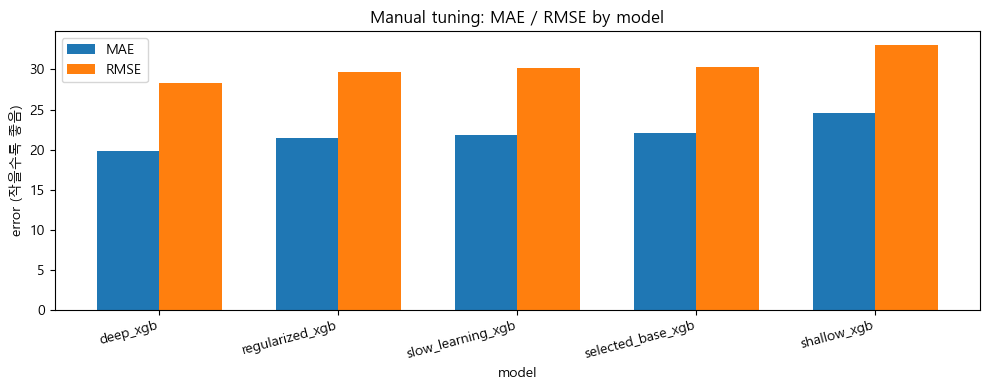

In [39]:
# 수동 튜닝 모델들의 MAE / RMSE 를 막대그래프로 비교합니다.
names = manual_comparison_df["model_name"].tolist()
x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(10, 4))
plt.bar(x - width / 2, manual_comparison_df["MAE"], width, label="MAE")
plt.bar(x + width / 2, manual_comparison_df["RMSE"], width, label="RMSE")
plt.title("Manual tuning: MAE / RMSE by model")
plt.xlabel("model")
plt.ylabel("error (작을수록 좋음)")
plt.xticks(x, names, rotation=15, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 14. RandomizedSearchCV를 사용하는 이유

수동 튜닝은 의미를 이해하기 좋지만, 사람이 모든 조합을 다 시도하기는 어렵습니다. 자동 탐색 도구로는 `GridSearchCV`와 `RandomizedSearchCV`가 있습니다.

- **`GridSearchCV`**: 지정한 **모든 조합을 전부** 확인합니다. 정확하지만 조합 수가 늘어나면 실행 시간이 **급격히** 늘어납니다. (예: 7개 파라미터에 각 4개 후보면 수천 ~ 수만 조합)
- **`RandomizedSearchCV`**: 후보 조합 중 **일부만 무작위로** 뽑아 확인합니다. 전부 확인하지는 않지만, 적은 횟수로 넓은 범위를 훑어볼 수 있어 수업 시간에 더 적합합니다.

유의할 점입니다.

- 무작위 탐색이므로 `random_state`를 지정해 **재현성**을 확보합니다. (같은 조합이 다시 뽑히도록)
- 이번 노트북에서는 실행 시간을 고려해 `n_iter`(시도 횟수)를 **10~20 사이**로 설정합니다. 실행이 오래 걸리면 10으로 줄일 수 있습니다.

## 15. Pipeline에서 파라미터 이름을 지정하는 방식

RandomizedSearchCV가 탐색할 파라미터를 알려 줄 때, **Pipeline 내부 어느 단계의 파라미터인지**를 함께 지정해야 합니다. 형식은 다음과 같습니다.

```
단계이름__파라미터명
```

- Pipeline은 전처리와 모델을 하나로 묶은 구조이므로, "이건 모델 단계의 설정"이라고 알려 줘야 합니다.
- 이번 Pipeline에서 XGBoost 단계 이름을 `"model"`로 만들었으므로, `model__max_depth`처럼 적습니다.
- **언더바(`_`)가 2개** 들어간다는 점을 꼭 기억하세요. (`model_max_depth`가 아니라 `model__max_depth`)

비유하자면, 큰 건물(Pipeline) 안에서 "몇 호실(단계)의 어떤 스위치(파라미터)"인지 **호실 번호와 스위치 이름을 같이** 불러 주는 것과 같습니다.

## 16. RandomizedSearchCV 준비 — 탐색 범위와 scoring

탐색할 파라미터 후보를 정의합니다. 실행 시간이 너무 길어지지 않도록 범위를 과하게 크게 잡지 않습니다.

scoring으로는 `neg_mean_absolute_error`를 사용합니다.

- scikit-learn은 점수가 **클수록 좋은** 방향으로 설계되어 있습니다.
- 그런데 MAE는 **작을수록 좋은** 지표입니다. 그래서 부호를 뒤집은 `neg_mean_absolute_error`(음수 MAE)를 사용합니다. (예: MAE 27 → -27, MAE 25 → -25 이므로 -25가 더 큰 값 = 더 좋음)
- 최종 해석할 때는 다시 **양수 MAE**로 바꿔서 이해합니다.

In [40]:
# 탐색할 하이퍼파라미터 후보입니다. Pipeline 모델 단계 이름이 "model" 이므로 "model__" 을 앞에 붙입니다.

param_distributions = {
    "model__max_depth": [3, 5, 7, 9],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__n_estimators": [200, 300, 400],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

# MAE 는 작을수록 좋으므로, 점수가 클수록 좋은 sklearn 규칙에 맞춰 음수 MAE 를 사용합니다.
scoring = "neg_mean_absolute_error"

print("탐색 대상 파라미터 수:", len(param_distributions))

탐색 대상 파라미터 수: 5


## 17. RandomizedSearchCV 실행

이제 자동 탐색을 실행합니다. 설정의 의미는 다음과 같습니다.

- `n_iter=15`: 후보 조합 중 15개만 무작위로 뽑아 확인합니다. (실행이 오래 걸리면 10으로 줄일 수 있습니다.)
- `cv=3`: train 데이터를 다시 3개로 나눠 내부 검증을 반복합니다. (교차검증)
- `n_jobs=-1`: **여러 조합을 동시에** 평가합니다.
- 내부 `XGBRegressor(n_jobs=1)`: 중첩 병렬을 피하려고 각 모델은 한 코어만 씁니다.
- `random_state=42`: 같은 조합이 다시 뽑히도록 고정합니다.
- `verbose=1`: 진행 상황을 출력합니다.

중요한 점입니다.

- RandomizedSearchCV는 **train 데이터 내부에서** 여러 번 검증을 수행합니다. 그 cv 점수는 **train을 다시 나눈 내부 검증 점수**입니다.
- **test 데이터는 튜닝에 직접 사용하지 않고**, 마지막 비교를 위해 남겨 둡니다.
- test 데이터로 계속 튜닝하면, test set에만 맞춰진 모델이 되어 실제 성능을 잘못 판단할 수 있습니다.
- `RandomizedSearchCV(n_jobs=-1)` + `XGBRegressor(n_jobs=1)` 조합은 CPU를 과도하게 쓰는 중첩 병렬을 줄여 줍니다.

In [41]:
# 탐색에 사용할 Pipeline 입니다. 내부 XGBoost 는 n_jobs=1 로 두어 중첩 병렬을 피합니다.
search_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1,   # 중첩 병렬 방지: 바깥 RandomizedSearchCV 가 병렬을 담당합니다.
    )),
])



In [42]:
# RandomizedSearchCV 를 구성합니다.
random_search = RandomizedSearchCV(
    estimator=search_model,
    param_distributions=param_distributions,
    n_iter=25,                  # 시도할 조합 수. 실행이 오래 걸리면 10 으로 줄일 수 있습니다.
    scoring="neg_mean_absolute_error",  # 음수 MAE (클수록 좋음)
    cv=5,                       # train 을 5개로 나눠 내부 교차검증
    random_state=42,            # 재현성
    n_jobs=-1,                  # 조합 단위 병렬 (바깥 병렬)
    verbose=1,                  # 진행 상황 출력
)



In [43]:
# 학습은 train 데이터 안에서만 이루어집니다. (test 는 사용하지 않습니다.)
# 데이터 규모와 조합 수에 따라 다소 시간이 걸릴 수 있습니다.
start_time = time.time()
random_search.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"RandomizedSearchCV 완료. 소요 시간: {elapsed:.1f}초")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
RandomizedSearchCV 완료. 소요 시간: 247.8초


## 18. 최적 파라미터 확인

탐색이 끝나면 가장 좋았던 조합과 그 점수를 확인합니다.

- `best_params_`: 탐색한 조합 중 **교차검증 기준으로 가장 좋은 설정**입니다.
- `best_score_`: train 데이터 내부 교차검증에서 얻은 **가장 좋은 점수**입니다. (여기서는 음수 MAE)
- 음수 MAE이므로 부호를 바꿔 **양수 MAE(`best_cv_mae`)**로 해석합니다.
- `best_cv_mae`는 **train 내부 교차검증** 결과이고, 곧 계산할 **test MAE**는 남겨 둔 test set에서 최종 확인한 결과입니다. 둘은 다를 수 있습니다.

In [44]:
# 교차검증 기준 가장 좋았던 하이퍼파라미터 조합
random_search.best_params_

{'model__subsample': 1.0,
 'model__n_estimators': 300,
 'model__max_depth': 9,
 'model__learning_rate': 0.1,
 'model__colsample_bytree': 0.8}

In [45]:
# 교차검증 기준 가장 좋았던 점수 (음수 MAE 형태)
random_search.best_score_

np.float64(-18.960441970825194)

In [46]:
# 음수 MAE 를 양수 MAE 로 변환해 해석합니다. (train 내부 교차검증 결과)
best_cv_mae = -random_search.best_score_
print(f"best_cv_mae (train 내부 교차검증 MAE): {best_cv_mae:.4f}")

best_cv_mae (train 내부 교차검증 MAE): 18.9604


## 19. RandomizedSearchCV 결과표 확인

최적 조합 하나만 보기보다, **상위 후보들을 함께** 보는 것이 좋습니다.

- 비슷한 성능의 조합이 여러 개라면, 그중 **더 단순한 모델**을 선택할 수도 있습니다.
- `std_test_score`(fold 간 점수의 표준편차)가 크면, fold마다 성능 차이가 큰 것이므로 **안정성**도 함께 봐야 합니다.

In [47]:
# cv_results_ 를 DataFrame 으로 변환합니다. 탐색한 모든 조합의 결과가 담겨 있습니다.
search_results_df = pd.DataFrame(random_search.cv_results_)

# 보기 좋게 핵심 컬럼만 골라 봅니다. (실제로 존재하는 컬럼만 선택해 오류를 피합니다.)
view_cols = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_model__n_estimators",
    "param_model__learning_rate",
    "param_model__max_depth",
    "param_model__subsample",
    "param_model__colsample_bytree",
    "param_model__reg_alpha",
    "param_model__reg_lambda",
]
view_cols = [c for c in view_cols if c in search_results_df.columns]
search_results_view = search_results_df[view_cols].copy()

# mean_test_score 는 음수 MAE 이므로, 보기 좋게 양수 MAE 컬럼을 추가합니다.
search_results_view["mean_cv_MAE"] = -search_results_view["mean_test_score"]

# 순위(rank) 기준으로 정렬해 상위 10개 조합을 봅니다.
search_results_view.sort_values("rank_test_score").head(10)

,rank_test_score,mean_test_score,std_test_score,param_model__n_estimators,param_model__learning_rate,param_model__max_depth,param_model__subsample,param_model__colsample_bytree,mean_cv_MAE
17,1,-18.960442,0.088598,300,0.10,9,1.0,0.8,18.960442
8,2,-19.016322,0.084431,200,0.10,9,0.8,0.8,19.016322
15,3,-19.059716,0.099184,400,0.10,7,0.8,0.8,19.059716
21,4,-19.119254,0.097049,400,0.05,9,1.0,1.0,19.119254
7,5,-19.176461,0.109134,400,0.10,7,1.0,0.8,19.176461
0,6,-19.222087,0.098880,300,0.05,9,1.0,1.0,19.222087
12,7,-19.240579,0.083949,400,0.03,9,0.8,1.0,19.240579
1,8,-19.490184,0.092748,200,0.03,9,1.0,0.8,19.490184
9,9,-19.542942,0.099823,200,0.03,9,0.8,0.8,19.542942
6,10,-19.612482,0.119698,200,0.10,7,0.8,1.0,19.612482


## 20. 최적 모델로 test set 평가

교차검증에서 좋았던 모델이 **남겨 둔 test set에서도** 좋은지 확인합니다.

- `best_estimator_`는 최적 파라미터로 **train 전체를 다시 학습한** Pipeline입니다.
- test set 평가는 **최종 확인용**입니다.
- `best_cv_mae`(train 내부 교차검증)와 test MAE는 다를 수 있습니다.
- test set 결과만 보고 탐색 범위를 계속 바꾸면, test set에 과하게 맞출 위험이 있습니다.

In [48]:
# 최적 파라미터로 학습된 모델을 가져옵니다.
best_model = random_search.best_estimator_

# 남겨 둔 test set 으로 예측합니다.
y_pred_best = best_model.predict(X_test)

# test set 기준으로 평가합니다. (튜닝 모델 이름: best_tuned_xgb)
best_result = evaluate_regression_model(
    model_name="best_tuned_xgb",
    description="RandomizedSearchCV로 선택한 최적 XGBoost 모델",
    y_true=y_test,
    y_pred=y_pred_best,
)

# train 내부 교차검증 MAE 와 test MAE 를 나란히 비교합니다.
print(f"best_cv_mae (train 내부 교차검증): {best_cv_mae:.4f}")
print(f"test MAE   (남겨 둔 test set):    {best_result['MAE']:.4f}")

[best_tuned_xgb] MAE: 18.8901 | RMSE: 27.7281 
best_cv_mae (train 내부 교차검증): 18.9604
test MAE   (남겨 둔 test set):    18.8901


## 21. selected_base_xgb vs 튜닝 모델 비교

선정 조건 기준 모델(`selected_base_xgb`), 수동 튜닝 모델, RandomizedSearchCV 최적 모델(`best_tuned_xgb`)을 한 표로 모아 비교합니다.

#### 비교 기준에 대한 안내

- 이번 비교는 **같은 노트북 안의 `selected_base_xgb`와 튜닝 모델** 사이의 비교입니다.
- 두 모델은 **같은 feature와 같은 데이터 조건(상위 1% 제거)**을 사용합니다. 따라서 성능 차이는 주로 **하이퍼파라미터 변경의 영향**으로 해석할 수 있습니다.
- 앞 노트북의 `v2_original` 결과와는 **단순 숫자 비교를 하지 않습니다.** (feature·데이터 조건이 다르기 때문입니다.)

해석 시 유념할 점입니다.

- 튜닝 모델이 기준 모델보다 **반드시 좋아지는 것은 아닙니다.**
- 성능 차이가 작다면, **더 단순한 모델**을 선택하는 것이 나을 수도 있습니다.
- 모델 선택은 성능·복잡도·해석 가능성·실행 시간을 **함께** 고려하는 과정입니다.

In [49]:
# 비교할 모든 모델의 평가 결과를 모읍니다. (기준 모델 selected_base_xgb 포함)
all_results = [
    selected_base_result["evaluation"],
    shallow_result["evaluation"],
    deep_result["evaluation"],
    slow_learning_result["evaluation"],
]

# 선택 실험 regularized_xgb 가 있으면 함께 포함합니다.
if "regularized_result" in dir():
    all_results.append(regularized_result["evaluation"])

# 자동 튜닝 최적 모델(best_tuned_xgb)도 포함합니다.
all_results.append(best_result)

# MAE 가 작은 순으로 정렬해 비교합니다. (model_name, MAE, RMSE, R2, description 포함)
comparison_df = pd.DataFrame(all_results).sort_values("MAE").reset_index(drop=True)
comparison_df[["model_name", "MAE", "RMSE","description"]]

,model_name,MAE,RMSE,description
0,best_tuned_xgb,18.890110,27.728134,RandomizedSearchCV로 선택한 최적 XGBoost 모델
1,deep_xgb,19.790970,28.363020,깊은 트리 (max_depth=8) — 복잡한 모델
2,regularized_xgb,21.386074,29.712848,과적합 완화 (subsample/colsample + reg_alpha/reg_la...
3,slow_learning_xgb,21.806526,30.155766,"천천히 많이 학습 (lr=0.03, n_estimators=400)"
4,selected_base_xgb,22.020264,30.353906,"선정 조건 기준 모델 (v2 + 위치 feature + 상위 1% 제거, 기본 파라미터)"
5,shallow_xgb,24.618511,33.110122,얕은 트리 (max_depth=3) — 단순한 모델


## 22. 실제값 vs 예측값 비교 (최적 모델)

최적 모델의 예측 결과를 행 단위로 살펴봅니다. 평가 지표 뒤에 가려진 **개별 오차**를 확인하기 위해서입니다.

앞 노트북에서 평균 지표만으로는 모델의 약점을 알기 어렵다고 했습니다. 그래서 이번에도 최적 모델의 MAE/RMSE만 보고 끝내지 않고, **큰 오차가 남아 있는 사례를 다시 확인**합니다.

- 튜닝 후에도 **큰 오차는 남을 수** 있습니다.
- 하이퍼파라미터 튜닝은 모든 문제를 해결하는 만능 방법이 아닙니다.
- 여전히 feature 개선, 이상치 분석, 검증 방식 개선이 필요할 수 있습니다.

In [50]:
# 최적 모델의 실제값/예측값/오차를 한 표로 만듭니다.
best_pred_compare_df = pd.DataFrame({
    "actual": y_test.values,                        # 실제 도착 시간
    "pred": y_pred_best,                            # 예측 도착 시간
    "error": y_test.values - y_pred_best,           # 오차 (양수=과소예측)
    "abs_error": np.abs(y_test.values - y_pred_best),  # 오차의 절댓값
})


In [51]:
# 절대 오차가 큰 상위 20건을 확인합니다. 튜닝 후에도 크게 틀리는 사례가 있는지 봅니다.
best_pred_compare_df.sort_values("abs_error", ascending=False).head(20)

,actual,pred,error,abs_error
41213,320,72.048325,247.951675,247.951675
8003,300,52.167431,247.832569,247.832569
33792,310,83.042023,226.957977,226.957977
1910,340,116.546394,223.453606,223.453606
27804,328,113.640015,214.359985,214.359985
8852,320,110.523262,209.476738,209.476738
1045,288,82.316727,205.683273,205.683273
13709,308,103.785606,204.214394,204.214394
20,338,135.025558,202.974442,202.974442
4062,272,72.243599,199.756401,199.756401


## 23. 튜닝 결과 해석

아래 항목들은 **위 셀의 실제 출력을 보고** 채워 나가며 해석하는 틀입니다. (결과를 미리 단정하지 않습니다.)

- 기준 모델(`selected_base_xgb`)과 튜닝 모델들의 MAE/RMSE/R2가 어떻게 달라졌나요?
- 수동 튜닝 실험 중 어떤 설정이 좋았나요? (얕은/깊은 트리, 천천히 많이 학습, 규제 설정)
- RandomizedSearchCV 최적 모델(`best_tuned_xgb`)이 기준 모델보다 나아졌나요? (위 개선량 표 참고)
- `best_cv_mae`(train 내부 교차검증)와 test MAE는 어떻게 다른가요? 차이가 크다면 무엇을 의심할 수 있나요?
- 성능 차이가 크지 않다면, 더 단순한 모델을 택하는 편이 나을 **가능성**이 있습니다.
- 이번에는 **feature와 데이터 조건을 고정하고 튜닝**했으므로, 이번 결과는 "파라미터 변경 효과"에 집중해서 볼 수 있습니다.
- 비교 기준은 앞 노트북의 `v2_original`이 아니라 **이번 노트북의 `selected_base_xgb`**임을 기억하세요.

> 해석에서는 "반드시 좋아진다" 같은 표현 대신, "확인할 수 있다 / 가능성이 있다 / 추가 검토가 필요하다"처럼 근거 기반 표현을 사용합니다.

## 24. 최적 모델 해석 1: 특성중요도

지금까지 최적 튜닝 모델(`best_tuned_xgb`)의 성능과 오차를 확인했습니다. 이제 **이 모델이 어떤 feature를 상대적으로 많이 사용했는지** 살펴봅니다.

- 시각화를 위해 **모델을 새로 학습하지 않습니다.** 이미 학습된 최적 모델(`best_model`)을 그대로 사용합니다.
- `best_model`은 RandomizedSearchCV가 찾은 최적 파라미터로 학습된 Pipeline입니다. (`best_model = random_search.best_estimator_`)

먼저 최적 모델 Pipeline에서 전처리기(`preprocessor`)와 XGBoost 모델(`model`)을 꺼냅니다.

In [52]:
# 이미 학습된 최적 모델(best_model)을 그대로 사용합니다. (모델을 새로 학습하지 않습니다.)
# best_model 은 (preprocessor -> model) 2단계로 이루어진 Pipeline 입니다.
best_preprocessor = best_model.named_steps["preprocessor"]  # 전처리기(OneHotEncoder 등)
best_xgb_model = best_model.named_steps["model"]            # 실제 XGBoost 모델

# Pipeline 단계 이름을 확인합니다. (단계 이름이 다르면 위 키를 그 이름에 맞게 바꿔야 합니다.)
print("최적 모델 Pipeline 단계:", list(best_model.named_steps.keys()))

최적 모델 Pipeline 단계: ['preprocessor', 'model']


### 변환 후 feature 기준 특성중요도 Top 30

OneHotEncoder를 거친 뒤 **실제 XGBoost 모델에 들어간 feature 이름**과 그 중요도를 함께 봅니다.

- DataFrame을 만들기 전에 **feature 이름 개수**와 **feature_importances_ 개수**가 같은지 먼저 확인합니다. 두 개수가 다르면 표를 만들 때 오류가 나기 때문입니다.

In [53]:
# 전처리(OneHotEncoder + passthrough) 이후 실제 모델에 들어간 feature 이름을 가져옵니다.
transformed_feature_names = best_preprocessor.get_feature_names_out()

# 표를 만들기 전에 두 개수를 반드시 확인합니다. (개수가 다르면 DataFrame 생성에서 오류가 납니다.)
print("전처리 후 feature 개수:", len(transformed_feature_names))
print("XGBoost feature importance 개수:", len(best_xgb_model.feature_importances_))

전처리 후 feature 개수: 743
XGBoost feature importance 개수: 743


In [54]:
# 세부 feature 이름과 중요도를 한 표로 모으고, 중요도가 큰 순으로 정렬합니다.
feature_importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": best_xgb_model.feature_importances_,
})
feature_importance_df = feature_importance_df.sort_values(
    "importance", ascending=False
).reset_index(drop=True)

display(feature_importance_df.head(20))

,feature,importance
0,cat__next_station_제주중앙여자고등학교(아라방면),0.063205
1,cat__now_station_성산환승정류장(고성리 회전교차로),0.047220
2,remainder__next_dist_to_up,0.036898
3,cat__now_station_원노형,0.031817
4,cat__next_station_제주중앙여자고등학교(광양방면),0.031475
5,cat__now_station_농협 하나로마트,0.028281
6,cat__next_station_성판악,0.027448
7,remainder__distance,0.023465
8,cat__now_station_성판악,0.021725
9,cat__dist_segment_name_up → up,0.018782


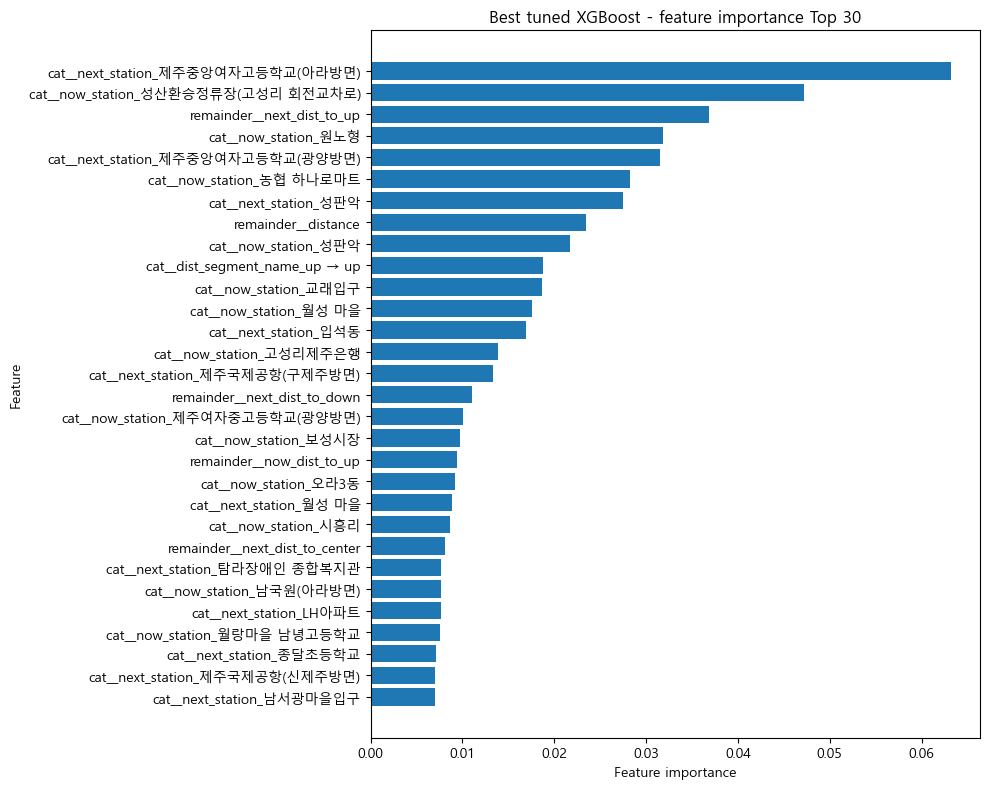

In [55]:
# 상위 30개 feature 를 수평 막대그래프로 그립니다.

top_n = 30
# 그래프는 아래에서 위로 그려지므로, 보기 좋게 오름차순으로 정렬합니다.
top_importance_df = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_importance_df["feature"], top_importance_df["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Best tuned XGBoost - feature importance Top 30")
plt.tight_layout()
plt.show()

이 그래프는 최적 튜닝 모델이 어떤 **세부 feature**를 상대적으로 중요하게 사용했는지 보여줍니다.

단, `route_nm`, `now_station`, `next_station` 같은 범주형 feature는 One-Hot Encoding 후 **여러 개의 0/1 컬럼으로 나뉩니다.** (예: `cat__now_station_제주공항`, `cat__now_station_시청` ...)

따라서 이 그래프는 "모델 내부에 들어간 **세부 feature 기준** 중요도"입니다. 사람이 한눈에 해석하기에는 컬럼이 많아 복잡할 수 있습니다.

### 원래 feature 단위로 묶은 특성중요도

위 그래프는 One-Hot Encoding 이후 쪼개진 세부 컬럼 기준이라 해석이 어렵습니다. 그래서 쪼개진 컬럼들을 **원래 feature 단위로 다시 묶어** 봅니다.

예를 들어 아래 세부 컬럼들의 중요도를 모두 합쳐 `now_station` 하나로 표시합니다.

```text
cat__now_station_제주공항
cat__now_station_동문로터리
cat__now_station_시청
        ↓
now_station
```

In [56]:
def get_original_feature_name(transformed_name, categorical_features, numeric_features):
    """
    OneHotEncoder 이후의 feature 이름을 원래 feature 이름으로 되돌려 보는 함수입니다.

    예:
    - cat__route_nm_201번 -> route_nm
    - cat__now_station_제주공항 -> now_station
    - remainder__distance -> distance

    주의:
    원래 feature 단위 중요도는 교육용 해석을 위한 보조 지표입니다.
    One-Hot feature를 원래 컬럼명 기준으로 묶은 것이므로,
    세부 feature importance와 완전히 같은 관점은 아닙니다.
    """
    # 범주형은 "cat__" 접두어가 붙습니다. 접두어를 떼고, 어느 원래 컬럼에서 나왔는지 찾습니다.
    if transformed_name.startswith("cat__"):
        name = transformed_name.replace("cat__", "", 1)
        for col in categorical_features:
            if name == col or name.startswith(col + "_"):
                return col
        return name

    # 숫자형(passthrough)은 "remainder__" 접두어가 붙습니다.
    if transformed_name.startswith("remainder__"):
        return transformed_name.replace("remainder__", "", 1)

    return transformed_name

In [57]:
# 각 세부 feature 가 어느 원래 feature 에서 나왔는지 표시한 뒤, 원래 feature 단위로 중요도를 합칩니다.
# (범주형 목록은 selected_categorical_features, 숫자형 목록은 selected_numeric_features 를 사용합니다.)
if len(transformed_feature_names) == len(best_xgb_model.feature_importances_):
    feature_importance_df["original_feature"] = feature_importance_df["feature"].apply(
        lambda x: get_original_feature_name(
            x,
            selected_categorical_features,
            selected_numeric_features,
        )
    )

    grouped_importance_df = (
        feature_importance_df
        .groupby("original_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    display(grouped_importance_df)

,original_feature,importance
0,now_station,0.463984
1,next_station,0.402405
2,next_dist_to_up,0.036898
3,distance,0.023465
4,dist_segment_name,0.021581
5,next_dist_to_down,0.011034
6,now_dist_to_up,0.009397
7,next_dist_to_center,0.008103
8,next_dist_to_right,0.006883
9,now_dist_to_down,0.005107


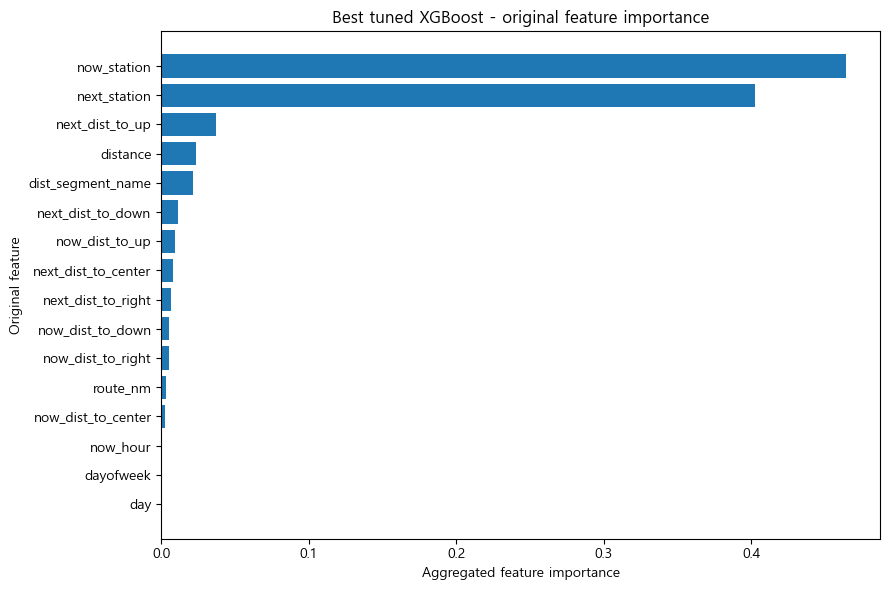

In [58]:
# 원래 feature 단위 중요도를 수평 막대그래프로 그립니다.
if len(transformed_feature_names) == len(best_xgb_model.feature_importances_):
    plot_grouped_df = grouped_importance_df.sort_values("importance")

    plt.figure(figsize=(9, 6))
    plt.barh(plot_grouped_df["original_feature"], plot_grouped_df["importance"])
    plt.xlabel("Aggregated feature importance")
    plt.ylabel("Original feature")
    plt.title("Best tuned XGBoost - original feature importance")
    plt.tight_layout()
    plt.show()

앞 그래프는 One-Hot Encoding 이후의 **세부 컬럼 기준** 중요도였습니다.

이번 그래프는 쪼개진 One-Hot feature를 다시 **원래 feature 단위로 묶은** 결과입니다. 예를 들어 `now_station` 관련 더미 컬럼들의 중요도를 모두 합쳐 `now_station` 하나로 표시합니다.

따라서 수강생 입장에서는 이 그래프가 더 해석하기 쉽습니다.

단, **원래 feature 단위 중요도는 교육용 해석을 위한 보조 지표**입니다. One-Hot feature를 원래 컬럼명 기준으로 묶은 것이므로 세부 feature importance와 완전히 같은 관점은 아닙니다. (과해석하지 않도록 주의합니다.)

## 25. 최적 모델 해석 2: dtreeviz로 XGBoost 내부 트리 저장

특성중요도가 "어떤 feature를 많이 썼는지"를 보여 줬다면, 이번에는 **XGBoost 내부의 결정트리가 어떤 조건으로 데이터를 나누는지**를 그림으로 저장해 봅니다. 이를 위해 `dtreeviz` 라이브러리를 사용합니다.

이 그림은 화면에 직접 출력하지 않고 **파일로 저장**합니다. (강의 자료로 보관하기 쉽고, 환경에 따라 화면 렌더링이 불안정할 수 있기 때문입니다.)

### dtreeviz 사용 전 주의사항

XGBoost는 하나의 큰 결정트리가 아니라, **여러 개의 작은 결정트리를 순서대로 쌓아** 예측하는 앙상블 모델입니다.

따라서 dtreeviz로 저장하는 그림은 XGBoost 전체 모델이 아니라, 최종 모델 안에 들어 있는 **여러 boosting tree 중 하나**입니다.

이 그림은 "모델 전체 판단을 완전히 설명하는 그림"이라기보다는, XGBoost 내부의 **개별 트리가 어떤 조건으로 데이터를 나누는지** 이해하기 위한 예시 시각화입니다.

`tree_index` 값을 바꾸면 다른 트리도 확인할 수 있습니다.

> 주의: dtreeviz 그림 하나가 최종 XGBoost 모델 전체를 의미하는 것은 아닙니다.

#### 설치 및 환경 안내

dtreeviz는 설치 및 환경 의존성이 있습니다. 주피터 노트북에서 아래 명령을 한 번 실행해 설치할 수 있습니다.

```text
!pip install dtreeviz graphviz
```

Windows에서 그래프 저장이 되지 않으면 Python 패키지 설치 외에 **Graphviz 프로그램 설치와 PATH 설정**이 필요할 수 있습니다.

- `pip install graphviz`는 Python 연결 패키지를 설치하는 것이고,
- **Graphviz 실행 프로그램은 별도로 설치**해야 할 수 있습니다.

설치/환경이 준비되지 않은 경우에도 노트북 전체 실행이 멈추지 않도록, 아래 저장 코드는 `try-except`로 감쌉니다.

In [59]:
# 저장 결과를 모아 둘 outputs 폴더를 준비합니다. (없으면 새로 만듭니다.)
import os

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)
print("저장 폴더 준비 완료:", os.path.abspath(output_dir))

저장 폴더 준비 완료: c:\ai_project01\outputs


### dtreeviz용 데이터 준비

dtreeviz는 트리가 데이터를 어떻게 나누는지 보여 주기 위해 **샘플 데이터**가 필요합니다.

**메모리 주의:** `X_train` 전체를 전처리 후 dense 배열로 바꾸면 메모리를 많이 차지할 수 있습니다. 그래서 전체를 변환하지 않고, **일부 샘플만 뽑아** 변환합니다.

순서는 다음과 같습니다.

1. 먼저 `X_train`에서 샘플 index를 뽑습니다.
2. 그 샘플만 `best_preprocessor.transform()`에 통과시킵니다.
3. 샘플 결과만 dense 배열로 변환합니다.
4. dtreeviz용 DataFrame을 만듭니다.

샘플 수는 강의 안정성을 위해 기본 1000개로 제한합니다. (데이터가 너무 크거나 메모리 문제가 있으면 `sample_size`를 500으로 줄일 수 있습니다.)

### tree_index=0 트리 저장

이제 최적 모델 내부의 **첫 번째 boosting tree(`tree_index=0`)**를 그림으로 저장합니다. 결과 그림은 화면에 직접 띄우지 않고 **`outputs` 폴더에 SVG(필요 시 PDF) 파일로 저장**합니다.

- 아래에는 dtreeviz 저장을 시도한 **여러 버전의 코드**가 있습니다. 위쪽의 주석 처리된 셀들은 환경·버전에 따라 시도했던 **참고용 대안**이고, 실제로 실행되는 셀은 **한글 feature 이름이 그림에 보이도록 처리한 버전**입니다. (학습용으로 시행착오 과정을 함께 남겨 두었습니다.)
- 한글이 깨지지 않도록, 그림에 표시할 feature 이름을 짧게 정리하고(예: `cat__now_station_제주공항` → `now_제주공항`), 저장한 SVG 안에 한글 폰트 스타일을 직접 넣어 줍니다.
- 환경 문제(주로 Graphviz 설치/PATH)로 저장이 실패해도 노트북 전체가 멈추지 않도록 `try-except`로 감쌌습니다. 실패해도 **앞의 튜닝·평가 결과에는 영향이 없습니다.**

> 참고: dtreeviz 그림에 feature 이름이 잘 나오도록, **같은 최적 파라미터를 쓰는 "시각화 전용 XGBoost 모델"**을 따로 학습해서 사용합니다. 이 시각화 전용 모델은 성능 평가용 최종 모델(`best_model`)을 **대체하지 않습니다.** (그림을 위한 보조 모델일 뿐입니다.)

In [61]:
# Graphviz가 Windows 폰트 폴더를 볼 수 있도록 보조 설정
os.environ["GDFONTPATH"] = r"C:\Windows\Fonts"

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

tree_index = 0

dtreeviz_svg_path = os.path.join(
    output_dir,
    f"xgboost_dtreeviz_tree_{tree_index}.svg"
)

dtreeviz_svg_path

'outputs\\xgboost_dtreeviz_tree_0.svg'

In [62]:
# ------------------------------------------------------------
# 1. 전처리 후 feature 이름 가져오기
# ------------------------------------------------------------
transformed_feature_names = list(best_preprocessor.get_feature_names_out())

transformed_feature_names

['cat__route_nm_201-11',
 'cat__route_nm_201-12',
 'cat__route_nm_201-13',
 'cat__route_nm_201-14',
 'cat__route_nm_201-15',
 'cat__route_nm_201-16',
 'cat__route_nm_201-17',
 'cat__route_nm_201-18',
 'cat__route_nm_201-21',
 'cat__route_nm_201-22',
 'cat__route_nm_201-24',
 'cat__route_nm_201-26',
 'cat__route_nm_201-27',
 'cat__route_nm_281-1',
 'cat__route_nm_281-2',
 'cat__route_nm_360-1',
 'cat__route_nm_360-12',
 'cat__route_nm_360-2',
 'cat__route_nm_360-7',
 'cat__route_nm_365-21',
 'cat__route_nm_365-22',
 'cat__now_station_911의원',
 'cat__now_station_LH아파트',
 'cat__now_station_가마초등학교',
 'cat__now_station_가흥동',
 'cat__now_station_거로 입구',
 'cat__now_station_견월교',
 'cat__now_station_계룡동',
 'cat__now_station_고도농원',
 'cat__now_station_고래왓',
 'cat__now_station_고망난돌입구',
 'cat__now_station_고산동산(광양방면)',
 'cat__now_station_고산동산(아라방면)',
 'cat__now_station_고성리 구 성산농협',
 'cat__now_station_고성리 성산농협',
 'cat__now_station_고성리제주은행',
 'cat__now_station_고성오일시장',
 'cat__now_station_고으니모르 국립제주박물관',

In [63]:
# ------------------------------------------------------------
# 2. dtreeviz에 표시할 짧은 feature 이름 만들기
# ------------------------------------------------------------
short_feature_names = []

for name in transformed_feature_names:
    short_name = (
        name
        .replace("cat__route_nm_", "route_")
        .replace("cat__now_station_", "now_")
        .replace("cat__next_station_", "next_")
        .replace("cat__dist_segment_name_", "segment_")
        .replace("remainder__", "")
    )
    short_feature_names.append(short_name)

short_feature_names



['route_201-11',
 'route_201-12',
 'route_201-13',
 'route_201-14',
 'route_201-15',
 'route_201-16',
 'route_201-17',
 'route_201-18',
 'route_201-21',
 'route_201-22',
 'route_201-24',
 'route_201-26',
 'route_201-27',
 'route_281-1',
 'route_281-2',
 'route_360-1',
 'route_360-12',
 'route_360-2',
 'route_360-7',
 'route_365-21',
 'route_365-22',
 'now_911의원',
 'now_LH아파트',
 'now_가마초등학교',
 'now_가흥동',
 'now_거로 입구',
 'now_견월교',
 'now_계룡동',
 'now_고도농원',
 'now_고래왓',
 'now_고망난돌입구',
 'now_고산동산(광양방면)',
 'now_고산동산(아라방면)',
 'now_고성리 구 성산농협',
 'now_고성리 성산농협',
 'now_고성리제주은행',
 'now_고성오일시장',
 'now_고으니모르 국립제주박물관',
 'now_공업단지 입구',
 'now_공천포',
 'now_관덕정',
 'now_광대왓',
 'now_광양',
 'now_광양사거리',
 'now_광지동',
 'now_광치기해변',
 'now_교래입구',
 'now_구 터미널',
 'now_구좌보건지소',
 'now_구좌중앙초등학교',
 'now_국립제주박물관',
 'now_그린카센터',
 'now_금붕사',
 'now_금산목',
 'now_김녕리',
 'now_김녕해수욕장',
 'now_김녕환승정류장(김녕초등학교)',
 'now_꽃동산',
 'now_난산입구',
 'now_난산입구(성산기상대)',
 'now_남국사',
 'now_남국원(광양방면)',
 'now_남국원(아라방면)',
 'now_남녕고등학교',
 'now_남서광마을',

In [65]:
# ------------------------------------------------------------
# 3. dtreeviz용 학습 데이터 생성
# ------------------------------------------------------------
# 전체 X_train을 전처리합니다.
# OneHotEncoder 결과가 sparse matrix일 수 있으므로,
# XGBoost 학습용으로 DataFrame을 만들기 위해 dense로 변환합니다.
#

X_train_transformed = best_preprocessor.transform(X_train)

X_train_transformed = X_train_transformed.toarray()

X_train_viz_df = pd.DataFrame(
    X_train_transformed,
    columns=short_feature_names,
    index=X_train.index,
)

print("dtreeviz용 학습 데이터 shape:", X_train_viz_df.shape)



dtreeviz용 학습 데이터 shape: (166684, 743)


In [66]:
# ------------------------------------------------------------
# 4. 기존 최적 XGBoost 파라미터 가져오기
# ------------------------------------------------------------
best_xgb_params = best_xgb_model.get_params()

viz_xgb_model = XGBRegressor(**best_xgb_params)


{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 9,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 300,
 'n_jobs': 1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 1.0,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=1, num_parallel_tree=None, ...)

In [68]:

# ------------------------------------------------------------
# 5. feature명이 있는 DataFrame으로 시각화 전용 모델 학습
# ------------------------------------------------------------
viz_xgb_model.fit(
    X_train_viz_df,
    y_train
)

print("dtreeviz용 XGBoost 모델 학습 완료")
print("booster feature_names 예시:")
print(viz_xgb_model.get_booster().feature_names[:20])



dtreeviz용 XGBoost 모델 학습 완료
booster feature_names 예시:
['route_201-11', 'route_201-12', 'route_201-13', 'route_201-14', 'route_201-15', 'route_201-16', 'route_201-17', 'route_201-18', 'route_201-21', 'route_201-22', 'route_201-24', 'route_201-26', 'route_201-27', 'route_281-1', 'route_281-2', 'route_360-1', 'route_360-12', 'route_360-2', 'route_360-7', 'route_365-21']


In [69]:
# ------------------------------------------------------------
# 6. dtreeviz용 샘플 데이터 준비
# ------------------------------------------------------------
sample_size = min( 1000, len(X_train_viz_df))

X_train_viz_sample = X_train_viz_df.sample(
    n=sample_size,
    random_state=42,
)

y_train_viz_sample = y_train.loc[X_train_viz_sample.index]

print("dtreeviz 시각화용 샘플 수:", len(X_train_viz_sample))



dtreeviz 시각화용 샘플 수: 1000


In [70]:
from dtreeviz import model as dtreeviz_model

# ------------------------------------------------------------
# 7. dtreeviz 생성
# ------------------------------------------------------------
viz = dtreeviz_model(
    viz_xgb_model,
    X_train_viz_sample,
    y_train_viz_sample,
    feature_names=list(X_train_viz_sample.columns),
    target_name=target_col,
    tree_index=tree_index,
)




In [71]:
# ------------------------------------------------------------
# 8. SVG 저장
# ------------------------------------------------------------
# 현재 dtreeviz 버전에서는 viz.view().save() 방식이 필요합니다.
viz_render = viz.view()
viz_render.save(dtreeviz_svg_path)

print("dtreeviz SVG 저장 완료:")
print(os.path.abspath(dtreeviz_svg_path))



dtreeviz SVG 저장 완료:
c:\ai_project01\outputs\xgboost_dtreeviz_tree_0.svg


In [72]:
# ------------------------------------------------------------
# 9. SVG 내부에 한글 폰트 스타일 삽입
# ------------------------------------------------------------
svg_file = Path(dtreeviz_svg_path)
svg_text = svg_file.read_text(encoding="utf-8")

korean_font_style = """
<style>
text {
font-family: "Malgun Gothic", "맑은 고딕", "Noto Sans CJK KR", sans-serif !important;
}
</style>
"""

# <svg ...> 태그 바로 뒤에 style 삽입
insert_pos = svg_text.find(">") + 1
svg_text = svg_text[:insert_pos] + korean_font_style + svg_text[insert_pos:]

svg_file.write_text(svg_text, encoding="utf-8")

print("SVG 파일에 한글 폰트 스타일을 추가했습니다.")




SVG 파일에 한글 폰트 스타일을 추가했습니다.


## 26. 최적 모델 시각화 결과 해석

이번 시각화 파트에서 확인한 내용을 정리합니다.

1. **특성중요도**는 최적 모델이 어떤 feature를 상대적으로 많이 사용했는지 보여 줍니다.
2. **One-Hot Encoding 이후 feature 기준 중요도**는 모델 내부 기준으로는 정확하지만, 컬럼이 많이 쪼개져 사람이 해석하기에는 복잡할 수 있습니다.
3. **원래 feature 단위 중요도**는 강의 해석용으로 더 적합합니다.
4. 다만 원래 feature 단위 중요도는 One-Hot feature를 묶은 **보조 해석 지표**이므로 과해석하지 않습니다.
5. **dtreeviz**는 XGBoost 전체가 아니라 **내부 boosting tree 하나**를 저장한 것입니다.
6. 따라서 dtreeviz는 전체 모델 설명이 아니라, **XGBoost 내부 분기 방식**을 이해하기 위한 예시로 해석해야 합니다.
7. 저장된 dtreeviz 파일과 plot_tree 파일은 **`outputs` 폴더**에서 확인합니다.

> 정리: 특성중요도와 트리 시각화는 "모델이 무엇을 보고 판단하는지"를 사람이 이해하도록 돕는 도구입니다. 단, 각 그림이 보여 주는 범위(세부 feature / 묶은 feature / 트리 하나)를 구분해서 해석하는 것이 중요합니다.

## 27. 이번 노트북에서 모델을 저장하지 않는 이유

이번 노트북에서는 모델을 파일로 저장하지 않습니다.

- 이번 노트북은 **하이퍼파라미터 튜닝 실험**을 위한 자료입니다.
- 아직 **날짜 기준 검증**, **최종 feature 확정**, **운영 입력값 정리** 등이 남아 있습니다.
- 따라서 이번 단계에서 모델을 저장해 **최종 모델처럼 다루지 않습니다.** (실험 중간 결과를 최종본으로 오해하지 않기 위해서입니다.)
- 모델 저장은 이후 **최종 모델 정리 노트북**에서 다룹니다.

비유하자면, 아직 **시제품을 여러 개 만들어 비교하는 단계**입니다. 어떤 것을 양산할지 정하기 전에는 한 시제품을 "완성품"으로 포장하지 않습니다.

## 28. 복습 질문

스스로 답해 보며 핵심을 정리해 보세요. (길게 적기보다 먼저 머릿속으로 설명해 보는 것이 목적입니다.)

1. 하이퍼파라미터는 모델 학습 과정에서 어떤 역할을 하나요?
2. feature를 고정하고 파라미터만 바꿔 비교해야 하는 이유는 무엇인가요?
3. `n_estimators`가 너무 작거나 너무 크면 어떤 문제가 생길 수 있나요?
4. `learning_rate`가 너무 크거나 너무 작으면 어떤 문제가 생길 수 있나요?
5. `max_depth`가 깊어질수록 모델은 어떤 방향으로 변하나요?
6. `subsample`과 `colsample_bytree`는 과적합 완화에 어떻게 도움을 줄 수 있나요?
7. `reg_alpha`, `reg_lambda`는 어떤 목적으로 사용하나요?
8. GridSearchCV와 RandomizedSearchCV의 차이는 무엇인가요?
9. Pipeline에서 `model__max_depth`처럼 언더바 두 개를 사용하는 이유는 무엇인가요?
10. `neg_mean_absolute_error`를 사용하는 이유는 무엇인가요?
11. RandomizedSearchCV의 cv 점수와 test set 점수는 어떻게 다른가요?
12. `best_cv_mae`와 test MAE가 다를 수 있는 이유는 무엇인가요?
13. RandomizedSearchCV에서 test set을 직접 튜닝에 사용하지 않는 이유는 무엇인가요?
14. 튜닝 모델이 기준 모델보다 성능이 좋아지지 않을 수도 있는 이유는 무엇인가요?
15. 성능 차이가 작다면 어떤 기준으로 모델을 선택할 수 있나요?
16. 하이퍼파라미터 튜닝 이후에도 추가로 검토해야 할 사항은 무엇인가요?
17. 이번 노트북에서 모델 저장을 하지 않는 이유는 무엇인가요?

## 29. 개선 방향 정리

#### 이번 노트북에서 한 일

- 앞 노트북의 실험 결과를 바탕으로 **최종 후보 조건**을 선택했습니다. (v2 기본 feature + 위치 feature + 상위 1% 이상치 제거)
- 위치 관련 feature(`dist_segment_name`, 기준점까지의 거리)를 생성했습니다.
- 상위 1% target 이상치를 **학습 전에** 제거해 데이터 조건을 고정했습니다.
- 선정 조건 기준 모델(`selected_base_xgb`)을 학습했습니다.
- 주요 하이퍼파라미터의 의미를 확인했습니다.
- 수동 튜닝 실험을 진행했습니다. (얕은/깊은 트리, 천천히 많이 학습, 과적합 완화)
- RandomizedSearchCV로 자동 탐색을 수행했습니다.
- `selected_base_xgb`와 튜닝 모델의 성능·개선량을 비교했습니다.
- 최적 모델(`best_tuned_xgb`)의 실제값과 예측값 차이를 확인했습니다.
- 이번 단계에서는 모델을 저장하지 않는 이유를 정리했습니다.

#### 다음 단계 제안

- 날짜 기준 train/test split (과거로 학습, 미래로 검증)
- random split과 time-based split의 결과 비교
- 범주형 고유값이 많은 컬럼의 처리 방식 개선
- 이상치 처리 정책 최종 정리
- 최종 feature 확정 및 최종 모델 저장
- 간단한 예측 앱 구성

> 하이퍼파라미터 튜닝은 성능을 자동으로 올려주는 마법이 아니라, 기준 모델과 평가 방식을 고정한 상태에서 학습 설정의 영향을 비교하는 실험 과정이다.